In [15]:
# M5 - Réseau de Neurones (MLP) + Target Encoding + Optuna Tuning

# 1. IMPORTATIONS POUR LE M5 (Réseau de Neurones)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.inspection import permutation_importance

# Preprocessing classique
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, StandardScaler
from category_encoders import TargetEncoder
from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer

# Outils pour la sélection de variables et l'optimisation
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LassoCV
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner
from optuna.exceptions import TrialPruned

# Le nouveau modèle : Réseau de Neurones Scikit-Learn
from sklearn.neural_network import MLPRegressor

In [16]:
# 2. CHARGEMENT DES DONNÉES ET PREPARATION DE LA TARGET

def advanced_feature_engineering(data):
    """
    Applique les transformations métiers sur le jeu de données.
    Note : L'encodage ordinal et les variables combinées (TotalSF, TotalBath, IsRemodeled)
    sont inspirés de stratégies performantes trouvées sur les notebooks publics de Kaggle.
    """
    df = data.copy()

    # --- A. CRÉATION DE VARIABLES (Inspiration Kaggle) ---
    # 1. Surface totale (Sous-sol + RDC + 1er étage)
    df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']

    # 2. Salles de bain totales (Les "HalfBath" comptent pour 0.5)
    df['TotalBath'] = df['FullBath'] + 0.5 * df['HalfBath'] + df['BsmtFullBath'] + 0.5 * df['BsmtHalfBath']

    # 3. Rénovation (Flag binaire : 1 si rénové, 0 sinon)
    df['IsRemodeled'] = (df['YearBuilt'] != df['YearRemodAdd']).astype(int)

    # --- B. ENCODAGE ORDINAL (Inspiration Kaggle) ---
    # On force la qualité en chiffres pour créer une hiérarchie stricte pour le Random Forest
    ordinal_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond',
                    'HeatingQC', 'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond']
    quality_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0, np.nan: 0}

    for col in ordinal_cols:
        if col in df.columns:
            df[col] = df[col].map(quality_map)

    # --- C. GESTION DES DATES (Calcul des âges) ---
    df['AgeBuilt'] = df['YrSold'] - df['YearBuilt']
    df['AgeRemodAdd'] = df['YrSold'] - df['YearRemodAdd']
    df['AgeGarage'] = df['YrSold'] - df['GarageYrBlt']

    # On supprime les anciennes dates brutes qui perturbent le modèle
    df = df.drop(['YearBuilt', 'YearRemodAdd', 'GarageYrBlt'], axis=1)

    return df


# --- 1. Chargement brut ---
train_df = pd.read_csv('Data/train.csv')
test_df = pd.read_csv('Data/test.csv')

# --- 2. Nettoyage des Outliers (SUR LE TRAIN UNIQUEMENT) ---
# Suppression des 2 transactions aberrantes repérées visuellement (>4000 sqft & <300000$)
train_df = train_df.drop(train_df[train_df['GrLivArea'] > 4000].index)

# --- 3. Feature Engineering ---
train_df = advanced_feature_engineering(train_df)
test_df = advanced_feature_engineering(test_df)

# --- 4. Séparation X et y ---
X_train = train_df.drop(['Id', 'SalePrice'], axis=1)
y_train = pd.Series(np.log1p(train_df['SalePrice']), index=train_df.index)

X_test = test_df.drop(['Id'], axis=1)
test_ids = test_df['Id']

In [17]:
# 3. CRÉATION DU PREPROCESSOR (Optimisé pour Réseau de Neurones)

# Redétection dynamique des colonnes après les changements de l'étape 2
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X_train.select_dtypes(include=['object']).columns

# 1. Identification des "faux manquants"
cat_none_features = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
                     'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
                     'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
                     'BsmtFinType2', 'MasVnrType']

# Les autres catégorielles
cat_freq_features = [col for col in categorical_features if col not in cat_none_features]

# 2. Pipeline Numérique : Imputation + Scaling (Inchangé)
numeric_transformer = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', RobustScaler())
])

# 3. Pipeline Catégorielle 1 : Imputation + Encodage + NOUVEAU SCALING
cat_none_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='None')),
    ('target_encoder', TargetEncoder(smoothing=10, handle_unknown='value', handle_missing='value')),
    ('scaler', StandardScaler()) # <-- Le bouclier indispensable pour le MLP
])

# 4. Pipeline Catégorielle 2 : Imputation + Encodage + NOUVEAU SCALING
cat_freq_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('target_encoder', TargetEncoder(smoothing=10, handle_unknown='value', handle_missing='value')),
    ('scaler', StandardScaler()) # <-- Le bouclier indispensable pour le MLP
])

# 5. L'assembleur final (ColumnTransformer)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat_none', cat_none_transformer, cat_none_features),
        ('cat_freq', cat_freq_transformer, cat_freq_features)
    ])

In [18]:
# 3bis. DIAGNOSTIC DU PREPROCESSING
# Affichage des colonnes catégorielles et vérification du preprocessing

print("=" * 60)
print("DIAGNOSTIC DU PREPROCESSING (Target Encoding + Scaling)")
print("=" * 60)
print(f"\n📊 Variables numériques : {len(numeric_features)}")
print(f"   {list(numeric_features)[:5]}... (affichage tronqué)\n")

print(f"📂 Variables catégorielles : {len(categorical_features)}")
for col in categorical_features:
    card = X_train[col].nunique()
    print(f"   {col:20} → cardinalité: {card:3} (top: {X_train[col].value_counts().index[0]})")

print(f"\n✔️  ÉTAPE 1 : Target Encoding va traduire chaque catégorie en prix moyen")
print(f"✔️  ÉTAPE 2 : StandardScaler va normaliser ces prix pour protéger le Réseau de Neurones")
print("=" * 60)

DIAGNOSTIC DU PREPROCESSING (Target Encoding + Scaling)

📊 Variables numériques : 48
   ['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond']... (affichage tronqué)

📂 Variables catégorielles : 34
   MSZoning             → cardinalité:   5 (top: RL)
   Street               → cardinalité:   2 (top: Pave)
   Alley                → cardinalité:   2 (top: Grvl)
   LotShape             → cardinalité:   4 (top: Reg)
   LandContour          → cardinalité:   4 (top: Lvl)
   Utilities            → cardinalité:   2 (top: AllPub)
   LotConfig            → cardinalité:   5 (top: Inside)
   LandSlope            → cardinalité:   3 (top: Gtl)
   Neighborhood         → cardinalité:  25 (top: NAmes)
   Condition1           → cardinalité:   9 (top: Norm)
   Condition2           → cardinalité:   8 (top: Norm)
   BldgType             → cardinalité:   5 (top: 1Fam)
   HouseStyle           → cardinalité:   8 (top: 1Story)
   RoofStyle            → cardinalité:   6 (top: Gable)
   RoofMatl  

In [19]:
# 4. CONSTRUCTION DE LA PIPELINE HYBRIDE ET TUNING (M5 - Réseau de Neurones)

# Étape A : Le Filtre Lasso
feature_selector = SelectFromModel(LassoCV(cv=5, random_state=42))

# Étape B : L'Optimisation avec Optuna (Architecture Dynamique)
def objective(trial):
    """
    Fonction objective pour Optuna : génère dynamiquement le nombre de couches
    et de neurones, teste la combinaison et retourne le RMSE moyen.
    """
    # 1. OPTUNA DÉCIDE DU NOMBRE DE COUCHES (de 0 à 3)
    # 0 couche = Ton idée du neurone unique (Modèle linéaire)
    n_layers = trial.suggest_int('n_layers', 0, 3)

    # 2. OPTUNA DÉCIDE DU NOMBRE DE NEURONES PAR COUCHE
    layers = []
    if n_layers > 0:
        for i in range(n_layers):
            # On teste entre 10 et 200 neurones par couche, par pas de 10
            n_units = trial.suggest_int(f'n_units_layer_{i}', 10, 200, step=10)
            layers.append(n_units)

    hidden_layer_sizes = tuple(layers) # Conversion au format attendu par Sklearn : () ou (X,) ou (X, Y)

    # 3. Autres hyperparamètres classiques
    activation = trial.suggest_categorical('activation', ['relu', 'tanh'])
    solver = trial.suggest_categorical('solver', ['adam'])
    alpha = trial.suggest_float('alpha', 1e-5, 1e-2, log=True)
    learning_rate_init = trial.suggest_float('learning_rate_init', 1e-4, 1e-2, log=True)

    # Création du modèle avec l'architecture générée dynamiquement
    mlp_model_trial = MLPRegressor(
        hidden_layer_sizes=hidden_layer_sizes,
        activation=activation,
        solver=solver,
        alpha=alpha,
        learning_rate_init=learning_rate_init,
        max_iter=1000,
        early_stopping=False,
        random_state=42
    )

    pipeline_trial = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('selector', feature_selector),
        ('mlp', mlp_model_trial)
    ])

    kf = KFold(n_splits=3, shuffle=True, random_state=42)
    fold_scores = []

    for train_idx, val_idx in kf.split(X_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        pipeline_trial.fit(X_tr, y_tr)
        preds = pipeline_trial.predict(X_val)

        rmse = np.sqrt(mean_squared_error(y_val, preds))
        fold_scores.append(-rmse)

    return float(np.mean(fold_scores))


# Étape C : Lancement de l'étude Optuna
print("Lancement de l'optimisation Optuna pour le Réseau de Neurones...")
print("Recherche dynamique d'architecture de couches complexes...\n")

sampler = TPESampler(seed=42)
study = optuna.create_study(direction='maximize', sampler=sampler)
study.optimize(objective, n_trials=40, show_progress_bar=True)

print("-" * 50)
print("Optimisation terminée !")
print(f"Meilleur score CV (neg_rmse) : {study.best_value:.4f}")
print(f"Meilleurs hyperparamètres trouvés :\n{study.best_params}")
print("-" * 50)


# Étape D : Réentraîner le meilleur modèle sur tout le jeu de données
best_params = study.best_params

# Reconstitution dynamique du tuple de couches à partir des meilleurs paramètres trouvables
best_layers = []
if best_params['n_layers'] > 0:
    for i in range(best_params['n_layers']):
        best_layers.append(best_params[f'n_units_layer_{i}'])
best_hidden_layer_sizes = tuple(best_layers)

mlp_best = MLPRegressor(
    hidden_layer_sizes=best_hidden_layer_sizes,
    activation=best_params['activation'],
    solver=best_params['solver'],
    alpha=best_params['alpha'],
    learning_rate_init=best_params['learning_rate_init'],
    max_iter=1500,
    early_stopping=False,
    random_state=42
)

best_m5_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('selector', feature_selector),
    ('mlp', mlp_best)
])

# Fit final sans encombre
best_m5_pipeline.fit(X_train, y_train)

# Évaluation finale sur le Train Set
y_pred_train = best_m5_pipeline.predict(X_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
print(f"Architecture finale retenue : {best_hidden_layer_sizes}")
print(f"RMSE (Log) sur le Train Set avec MLP final : {rmse_train:.4f}")

[I 2026-05-24 14:43:19,261] A new study created in memory with name: no-name-dd8b1e0b-2b3c-4eab-9edd-57c712527837


Lancement de l'optimisation Optuna pour le Réseau de Neurones...
Recherche dynamique d'architecture de couches complexes...



  0%|          | 0/40 [00:00<?, ?it/s]/home/awalther/anaconda3/envs/dataScience/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/awalther/anaconda3/envs/dataScience/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
Best trial: 0. Best value: -2.03048:   2%|▎         | 1/40 [00:11<07:26, 11.44s/it]

[I 2026-05-24 14:43:30,700] Trial 0 finished with value: -2.030478595209109 and parameters: {'n_layers': 1, 'n_units_layer_0': 200, 'activation': 'relu', 'solver': 'adam', 'alpha': 2.9380279387035334e-05, 'learning_rate_init': 0.00020511104188433984}. Best is trial 0 with value: -2.030478595209109.


/home/awalther/anaconda3/envs/dataScience/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/awalther/anaconda3/envs/dataScience/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/awalther/anaconda3/envs/dataScience/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
Best trial: 0. Best value: -2.03048:   5%|▌         | 2/40 [00:14<04:03,  6.40s/it]

...

[I 2026-05-24 14:47:54,353] Trial 37 finished with value: -0.8695260226389546 and parameters: {'n_layers': 2, 'n_units_layer_0': 50, 'n_units_layer_1': 110, 'activation': 'tanh', 'solver': 'adam', 'alpha': 2.7409233865259343e-05, 'learning_rate_init': 0.0008582832138634933}. Best is trial 24 with value: -0.22708282744575756.


Best trial: 24. Best value: -0.227083:  98%|█████████▊| 39/40 [04:40<00:05,  5.58s/it]

[I 2026-05-24 14:47:59,560] Trial 38 finished with value: -0.2448796840731808 and parameters: {'n_layers': 3, 'n_units_layer_0': 20, 'n_units_layer_1': 150, 'n_units_layer_2': 180, 'activation': 'tanh', 'solver': 'adam', 'alpha': 3.222171558735319e-05, 'learning_rate_init': 0.0059191809853547045}. Best is trial 24 with value: -0.22708282744575756.


Best trial: 24. Best value: -0.227083: 100%|██████████| 40/40 [04:42<00:00,  7.06s/it]


[I 2026-05-24 14:48:01,782] Trial 39 finished with value: -2.0557699276862462 and parameters: {'n_layers': 3, 'n_units_layer_0': 70, 'n_units_layer_1': 130, 'n_units_layer_2': 90, 'activation': 'relu', 'solver': 'adam', 'alpha': 0.0001672970840090178, 'learning_rate_init': 0.008157240111128646}. Best is trial 24 with value: -0.22708282744575756.
--------------------------------------------------
Optimisation terminée !
Meilleur score CV (neg_rmse) : -0.2271
Meilleurs hyperparamètres trouvés :
{'n_layers': 3, 'n_units_layer_0': 10, 'n_units_layer_1': 150, 'n_units_layer_2': 170, 'activation': 'tanh', 'solver': 'adam', 'alpha': 4.2899743940599205e-05, 'learning_rate_init': 0.002250156272938391}
--------------------------------------------------
Architecture finale retenue : (10, 150, 170)
RMSE (Log) sur le Train Set avec MLP final : 0.1825


In [22]:
# 5. GÉNÉRATION DE LA SOUMISSION KAGGLE

# On prédit avec le meilleur modèle trouvé
preds_log_m5 = best_m5_pipeline.predict(X_test)
preds_dollars_m5 = np.expm1(preds_log_m5) # Retour au prix en dollars

submission_m5 = pd.DataFrame({
    'Id': test_ids,
    'SalePrice': preds_dollars_m5
})

fichier_soumission = 'M5_NeuralNetwork_Submission.csv'
submission_m5.to_csv(fichier_soumission, index=False)
print(f"Fichier '{fichier_soumission}' prêt ! Envoie-le sur Kaggle pour voir notre nouveau score.")

Fichier 'M5_NeuralNetwork_Submission.csv' prêt ! Envoie-le sur Kaggle pour voir notre nouveau score.


Calcul de l'importance des variables par permutation (cela peut prendre quelques secondes)...


/tmp/ipykernel_136886/3733634311.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Importance', y='Variable', palette='magma')


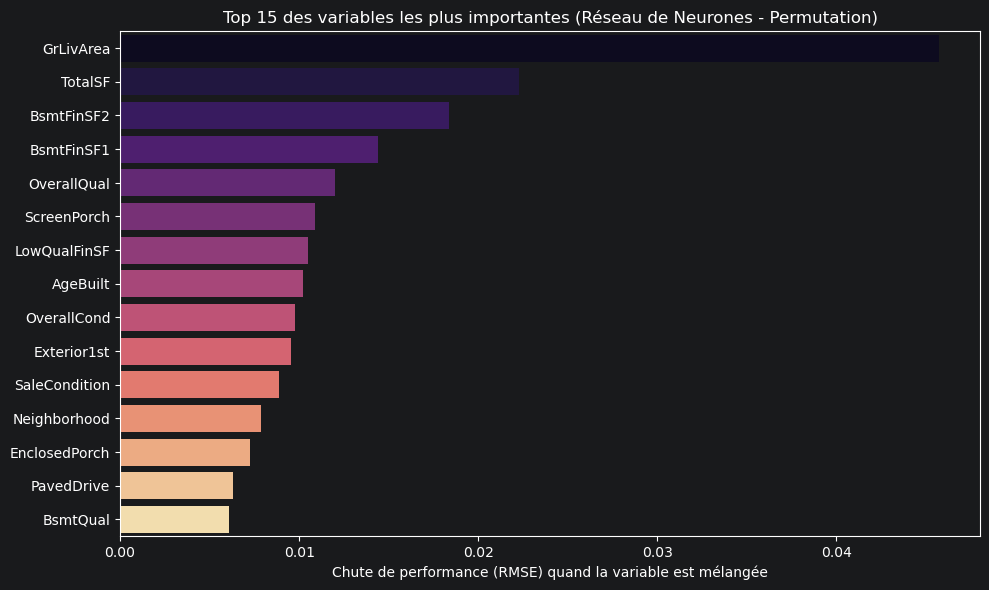

In [23]:
print("Calcul de l'importance des variables par permutation (cela peut prendre quelques secondes)...")

# 1. Calcul de l'importance par permutation sur le Train Set
# n_repeats=5 signifie qu'on mélange 5 fois chaque colonne pour faire une moyenne stable
result = permutation_importance(
    best_m5_pipeline, # Ta pipeline finale avec le réseau de neurones
    X_train,
    y_train,
    n_repeats=5,
    random_state=42,
    scoring='neg_root_mean_squared_error'
)

# 2. Récupération directe des noms originaux de ton dataset
feature_names = X_train.columns

# 3. Création d'un tableau propre
importance_df = pd.DataFrame({
    'Variable': feature_names,
    'Importance': result.importances_mean
})

# 4. Tri et sélection du Top 15
# (On garde uniquement les variables dont la perturbation fait baisser le modèle)
importance_df = importance_df[importance_df['Importance'] > 0]
importance_df = importance_df.sort_values(by='Importance', ascending=False).head(15)

# 5. Affichage du graphique final
plt.figure(figsize=(10, 6))
# J'ai changé la palette en 'magma' pour différencier visuellement du Random Forest
sns.barplot(data=importance_df, x='Importance', y='Variable', palette='magma')
plt.title('Top 15 des variables les plus importantes (Réseau de Neurones - Permutation)')
plt.xlabel('Chute de performance (RMSE) quand la variable est mélangée')
plt.ylabel('')
plt.tight_layout()
plt.show()